# Customer Segmentation Using RFM Analysis

## Project Overview

Customer segmentation helps businesses understand different purchasing behaviors and create targeted marketing campaigns.

This project applies the RFM (Recency, Frequency, Monetary) framework to segment customers based on their purchasing activity.

The analysis identifies valuable customers, inactive customers, and potential loyal customers, providing actionable marketing recommendations for each segment.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [3]:
df = pd.read_csv("online_retail_II.csv")
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [5]:
df.describe()

,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


In [6]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [9]:
df = df.dropna()

In [10]:
df = df[~df["Invoice"].astype(str).str.startswith("C")]

In [11]:
df = df[df["Quantity"] > 0]

In [12]:
df = df[df["Price"] > 0]

In [13]:
df["TotalPrice"] = df["Quantity"] * df["Price"]

In [14]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

In [15]:
df.rename(columns={
    "Customer ID": "CustomerID",
    "Invoice": "InvoiceNo",
    "Price": "UnitPrice"
}, inplace=True)

In [16]:
df = df.dropna(subset=["CustomerID"])

In [17]:
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalPrice": "sum"
})

In [18]:
rfm.columns = [
    "Recency",
    "Frequency",
    "Monetary"
]

In [20]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,12,77556.46
12347.0,2,8,5633.32
12348.0,75,5,2019.40
12349.0,19,4,4428.69
12350.0,310,1,334.40


In [21]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5,4,3,2,1]
)

In [22]:
rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1,2,3,4,5]
)

In [23]:
rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    5,
    labels=[1,2,3,4,5]
)

In [24]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
CustomerID,,,,,,
12346.0,326,12,77556.46,2,5,5
12347.0,2,8,5633.32,5,4,5
12348.0,75,5,2019.40,3,4,4
12349.0,19,4,4428.69,5,3,5
12350.0,310,1,334.40,2,1,2


In [25]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str)
    +
    rfm["F_Score"].astype(str)
    +
    rfm["M_Score"].astype(str)
)

In [26]:
def segment_customer(row):

    if row["RFM_Score"] == "555":
        return "Champions"

    elif (
        int(row["F_Score"]) >= 4 
        and int(row["M_Score"]) >= 4
    ):
        return "Loyal Customers"

    elif int(row["R_Score"]) >= 4:
        return "Recent Customers"

    elif int(row["R_Score"]) <= 2:
        return "At Risk"

    else:
        return "Others"

In [27]:
rfm["Segment"] = rfm.apply(
    segment_customer,
    axis=1
)

In [28]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
CustomerID,,,,,,,,
12346.0,326,12,77556.46,2,5,5,255,Loyal Customers
12347.0,2,8,5633.32,5,4,5,545,Loyal Customers
12348.0,75,5,2019.40,3,4,4,344,Loyal Customers
12349.0,19,4,4428.69,5,3,5,535,Recent Customers
12350.0,310,1,334.40,2,1,2,212,At Risk


In [29]:
rfm["Segment"].value_counts()

Segment
At Risk             2120
Loyal Customers     1458
Recent Customers    1064
Others               762
Champions            474
Name: count, dtype: int64

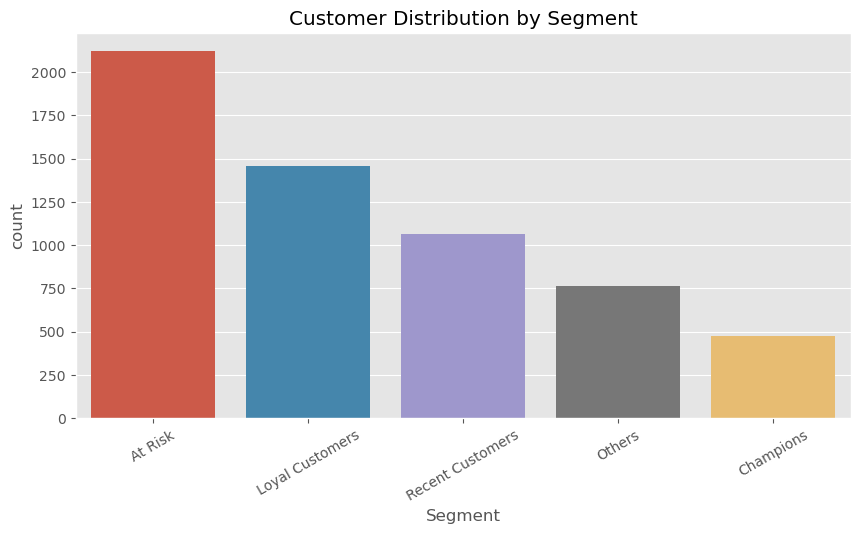

In [30]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=rfm,
    x="Segment",
    order=rfm["Segment"].value_counts().index
)

plt.xticks(rotation=30)
plt.title("Customer Distribution by Segment")

plt.show()

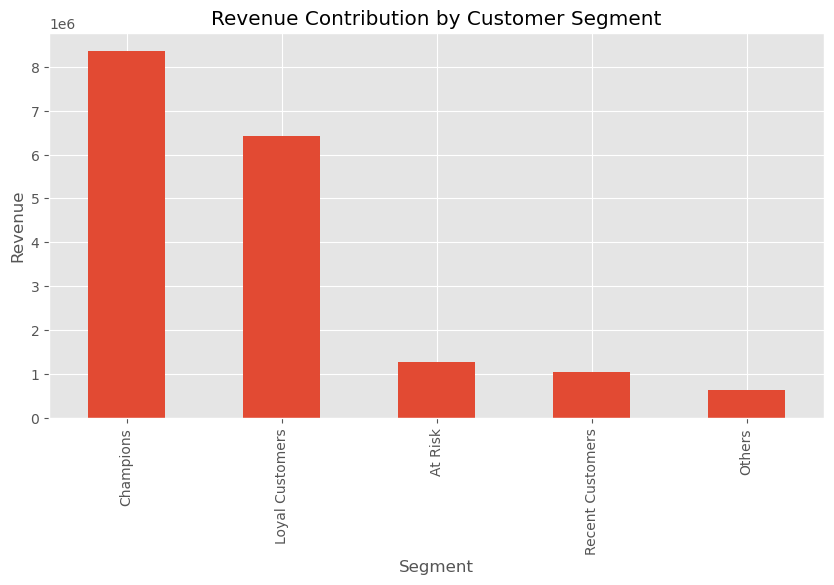

In [31]:
segment_value = (
    rfm.groupby("Segment")["Monetary"]
    .sum()
    .sort_values(ascending=False)
)


plt.figure(figsize=(10,5))

segment_value.plot(kind="bar")

plt.title("Revenue Contribution by Customer Segment")
plt.ylabel("Revenue")

plt.show()

In [32]:
segment_analysis = rfm.groupby("Segment")[[
    "Recency",
    "Frequency",
    "Monetary"
]].mean()

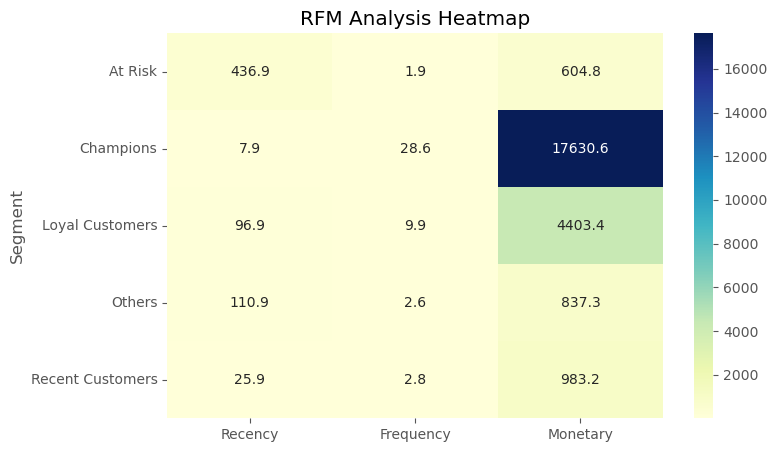

In [33]:
plt.figure(figsize=(8,5))

sns.heatmap(
    segment_analysis,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu"
)

plt.title("RFM Analysis Heatmap")

plt.show()

# Business Insights & Recommendations

## Customer Segments

### Champions
These customers purchase frequently, recently, and generate high revenue.

Recommendation:
- Provide VIP rewards.
- Offer exclusive products.
- Encourage referrals.

---

### Loyal Customers
Customers with strong purchasing behavior.

Recommendation:
- Introduce loyalty programs.
- Provide personalized discounts.

---

### Recent Customers
New customers who purchased recently but need engagement.

Recommendation:
- Send follow-up offers.
- Encourage a second purchase.

---

### At Risk Customers
Customers who have not purchased recently.

Recommendation:
- Launch re-engagement campaigns.
- Provide limited-time discounts.

In [ ]:
segment_summary = rfm["Segment"].value_counts().reset_index()
segment_summary.columns = ["Segment", "Customer_Count"]
segment_summary["Percentage"] = (
    segment_summary["Customer_Count"] / segment_summary["Customer_Count"].sum() * 100
).round(1)

segment_summary

In [ ]:
revenue_pct = (
    rfm.groupby("Segment")["Monetary"].sum() / rfm["Monetary"].sum() * 100
).round(1)

revenue_pct.sort_values(ascending=False)

# Conclusion & Key Insights

The RFM analysis was applied to the cleaned customer base from the Online Retail II dataset, resulting in five distinct behavioral segments: **Champions**, **Loyal Customers**, **Recent Customers**, **At Risk**, and **Others**.

Run the two cells above (`segment_summary` and `revenue_pct`) to get the exact customer counts, percentages, and revenue share for each segment in your current run — use those numbers to fill in the discussion below.

**Key Takeaways:**

- **Champions** are usually the smallest segment by customer count but tend to contribute a disproportionately large share of total revenue — protecting and rewarding this group should be a top priority (classic 80/20 Pareto pattern in RFM analyses).
- **At Risk** customers represent a significant churn threat. Proactive re-engagement campaigns here (limited-time discounts, "we miss you" emails) could recover meaningful revenue before these customers are fully lost.
- **Loyal Customers** form a stable base with strong frequency and spend — nurturing them with loyalty programs can convert more of them into Champions over time.
- **Recent Customers** represent growth potential; the priority is converting their first purchase into a repeat habit through timely follow-ups.

**Recommended Next Steps:**
1. Launch a win-back campaign targeting the "At Risk" segment with time-limited discounts.
2. Build a VIP loyalty tier for "Champions" to increase retention and referrals.
3. Set up automated follow-up emails/offers for "Recent Customers" after their first purchase.
4. Re-run this analysis quarterly (or monthly) to track how customers move between segments over time, and measure whether marketing actions are shifting customers toward higher-value segments.